# Steric Clash Detection in De Novo Protein Cores

** Proof-of-Concept for the Klavins Lab **

---

## Motivation

The December 2025 pre-print ["Using experimental results of protein design to guide biomolecular energy-function development"](https://www.biorxiv.org/content/10.64898/2025.12.12.691241v1) (Haddox, Rocklin, Park, Baker, DiMaio *et al.*) identified a systematic bias in the Rosetta `beta_nov16` energy function: the repulsive van der Waals term (`fa_rep`) under-penalizes **soft steric clashes** — subtle overpacking where nonpolar sidechain carbon atoms are forced to distances just below their equilibrium contact distance. Crystal structures of designed proteins showed ~30% fewer C–C clashing pairs than the corresponding Rosetta design models ([Rosetta Commons](https://rosettacommons.org/2026/01/28/using-protein-design-experiments-to-guide-energy-function-development/)).

### Previous Iteration

Our initial pipeline used a **2.5 Å** threshold (hard clashes). When tested on the HEEH_rd4_0640 design model, it found **zero clashes** — because Rosetta's energy minimization always resolves catastrophic sub-2.5 Å overlaps. The failures are subtler.

### This Iteration

We recalibrate to the **3.2 Å soft-clash regime** and remove the synthetic ML model (which was trained at the old threshold) in favor of a direct metric comparison between a positive and negative control.

| Protein | PDB | Type | Expected Stability |
|---------|-----|------|--------------------|
| **Top7** | [1QYS](https://www.rcsb.org/structure/1qys) | X-ray crystal structure (2.5 Å) | **Stable** — positive control |
| **HEEH_rd4_0640** | Rosetta model | Computational design (no exp. structure) | **Unstable** — negative control |

---

## Step 0 — Environment & Imports

In [7]:
!pip install biopython

In [8]:
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Any
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist
from Bio.PDB import PDBParser
from Bio.PDB.Structure import Structure

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
np.random.seed(42)

print("Environment ready.")

Environment ready.


---

## Step 1 — Threshold Recalibration: The 3.2 Å Soft-Clash Regime

### Biophysics of the 3.2 Å Threshold

The van der Waals contact distance between two non-bonded atoms equals the sum of their radii ([Bondi, 1964](https://en.wikipedia.org/wiki/Van_der_Waals_radius)). For the dominant interaction in hydrophobic cores — two Carbon atoms:

$$d_{\text{contact}}^{\text{C–C}} = r_{\text{vdW}}^{\text{C}} + r_{\text{vdW}}^{\text{C}} = 1.70 + 1.70 = 3.40 \;\text{Å}$$

A threshold of **3.2 Å** detects a **0.2 Å penetration** into the repulsive Lennard-Jones wall:

$$\delta = d_{\text{contact}} - d_{\text{observed}} = 3.40 - 3.20 = 0.20 \;\text{Å}$$

This is the **soft-clash regime** — atoms are not catastrophically overlapping (as at 2.5 Å), but they are compressed beyond their equilibrium distance, creating internal strain. This is precisely the regime where the Rosetta `fa_rep` term was systematically under-penalizing, as shown in the [pre-print](https://www.biorxiv.org/content/10.64898/2025.12.12.691241v1):

- At **2.5 Å** (our previous threshold): Rosetta's minimizer resolves these → 0 clashes in design models.
- At **3.2 Å** (this threshold): Rosetta permits these "soft" overlaps → detectable in design models.
- At **3.4 Å** (equilibrium contact): Normal packing — no overlap.

### Why This Matters

The pre-print's authors refit 15 Lennard-Jones parameters (radii and well depths for C and H atom types, global `fa_rep` weight) specifically to penalize this soft-clash regime more aggressively, producing the updated `beta_jan25` energy function.

In [9]:
# ============================================================
# RECALIBRATED THRESHOLD — soft-clash regime
# ============================================================
CLASH_THRESHOLD_ANGSTROM: float = 3.2

VDW_RADII: dict[str, float] = {"C": 1.70, "N": 1.55, "O": 1.52, "S": 1.80}
HEAVY_ELEMENTS: set[str] = set(VDW_RADII.keys())

print(f"Clash threshold set to {CLASH_THRESHOLD_ANGSTROM} Å")
print(f"C–C contact distance: {2 * VDW_RADII['C']:.2f} Å")
print(f"Overlap at threshold:  {2 * VDW_RADII['C'] - CLASH_THRESHOLD_ANGSTROM:.2f} Å")

Clash threshold set to 3.2 Å
C–C contact distance: 3.40 Å
Overlap at threshold:  0.20 Å


---

## Step 2 — PDB Parsing & Clash Detection Functions

In [10]:
def parse_pdb_heavy_atoms(
    pdb_path: str | Path,
    model_index: int = 0,
) -> tuple[np.ndarray, np.ndarray, list[str], list[str], list[str]]:
    """Parse a PDB → heavy-atom coords, residue IDs, elements, atom names, residue labels.
    Excludes hydrogens and heteroatoms (water, ligands)."""
    parser = PDBParser(QUIET=True)
    structure: Structure = parser.get_structure("protein", str(pdb_path))
    model = list(structure.get_models())[model_index]

    coords_list, resid_list, elem_list, aname_list, rlabel_list = [], [], [], [], []
    rc = 0

    for chain in model:
        for residue in chain:
            if residue.get_id()[0] != " ":
                continue
            rc += 1
            rl = f"{residue.get_resname()}{residue.get_id()[1]}"
            for atom in residue:
                el = atom.element.strip().upper()
                if el in HEAVY_ELEMENTS:
                    coords_list.append(atom.get_vector().get_array())
                    resid_list.append(rc)
                    elem_list.append(el)
                    aname_list.append(atom.get_name())
                    rlabel_list.append(rl)

    coords = np.array(coords_list, dtype=np.float64)
    residue_ids = np.array(resid_list, dtype=np.int64)
    print(f"Parsed {Path(pdb_path).name}: {coords.shape[0]} heavy atoms, {rc} residues")
    return coords, residue_ids, elem_list, aname_list, rlabel_list

In [11]:
def detect_steric_clashes(
    coords: np.ndarray,
    residue_ids: np.ndarray,
    elements: list[str],
    atom_names: list[str],
    res_labels: list[str],
    threshold: float = CLASH_THRESHOLD_ANGSTROM,
) -> dict[str, Any]:
    """Detect steric clashes between non-bonded heavy atoms.
    Excludes same-residue and adjacent-residue (backbone-bonded) pairs.

    Returns all-pair metrics AND Carbon-Carbon-specific metrics for
    comparison with the pre-print's methodology."""
    n_atoms = coords.shape[0]
    elements_arr = np.array(elements)
    dist_matrix = cdist(coords, coords, metric="euclidean")

    # Exclude same-residue and adjacent-residue pairs (covalent backbone)
    residue_gap = np.abs(residue_ids[:, np.newaxis] - residue_ids[np.newaxis, :])
    valid_mask = residue_gap > 1

    # --- All-atom clashes ---
    clash_mask = (dist_matrix < threshold) & valid_mask
    clash_count = int(np.sum(clash_mask)) // 2

    # --- Carbon-Carbon clashes only (matches pre-print methodology) ---
    carbon_mask = elements_arr == "C"
    cc_pair_mask = carbon_mask[:, np.newaxis] & carbon_mask[np.newaxis, :]
    cc_clash_mask = (dist_matrix < threshold) & valid_mask & cc_pair_mask
    cc_clash_count = int(np.sum(cc_clash_mask)) // 2
    n_carbon = int(np.sum(carbon_mask))

    # --- Avg core distance (non-bonded pairs within 5.0 Å) ---
    core_mask = (dist_matrix < 5.0) & (dist_matrix > 0.0) & valid_mask
    avg_core_dist = float(np.mean(dist_matrix[core_mask])) if np.any(core_mask) else 0.0

    # --- Enumerate clashing pairs by type ---
    ii, jj = np.where(np.triu(clash_mask, k=1))
    pair_type_counts: Counter = Counter()
    clash_pairs: list[dict] = []
    for i, j in zip(ii, jj):
        ptype = "-".join(sorted([elements[i], elements[j]]))
        pair_type_counts[ptype] += 1
        clash_pairs.append({
            "atom_i": f"{res_labels[i]}:{atom_names[i]}",
            "atom_j": f"{res_labels[j]}:{atom_names[j]}",
            "distance_A": round(dist_matrix[i, j], 3),
            "pair_type": ptype,
            "residue_gap": int(residue_gap[i, j]),
        })

    return {
        # All-atom metrics
        "Total_Atoms":       float(n_atoms),
        "Clash_Count":       float(clash_count),
        "Clash_Ratio":       clash_count / n_atoms if n_atoms > 0 else 0.0,
        "Avg_Core_Distance": round(avg_core_dist, 4),
        # Carbon-specific metrics
        "Carbon_Atoms":      float(n_carbon),
        "CC_Clash_Count":    float(cc_clash_count),
        "CC_Clash_Ratio":    cc_clash_count / n_carbon if n_carbon > 0 else 0.0,
        # Detail
        "pair_type_counts":  dict(pair_type_counts),
        "clash_pairs":       clash_pairs,
    }

---

## Step 3 — Analyze Both Structures at 3.2 Å

### ML Model — Suspended

The `RandomForestClassifier` from the previous iteration was trained on synthetic data calibrated to the 2.5 Å threshold. At 3.2 Å, the feature distributions are fundamentally different (clash counts increase by ~50–100×), so those model weights are invalid. The classifier will be retrained in a future iteration once we establish ground-truth feature distributions at the new threshold across a larger PDB dataset. For now, we compare raw metrics directly.

In [12]:
# ============================================================
# PARSE BOTH STRUCTURES
# ============================================================
top7_parsed = parse_pdb_heavy_atoms("1QYS.pdb")
heeh_parsed = parse_pdb_heavy_atoms("HEEH_rd4_0640_copy.pdb")

# ============================================================
# DETECT CLASHES AT 3.2 Å
# ============================================================
top7_metrics = detect_steric_clashes(*top7_parsed)
heeh_metrics = detect_steric_clashes(*heeh_parsed)

Parsed 1QYS.pdb: 677 heavy atoms, 91 residues
Parsed HEEH_rd4_0640_copy.pdb: 343 heavy atoms, 43 residues


In [13]:
def print_clash_report(name: str, m: dict) -> None:
    print(f"\n{'='*55}")
    print(f"  {name} — CLASH REPORT (threshold: {CLASH_THRESHOLD_ANGSTROM} Å)")
    print(f"{'='*55}")
    print(f"  Heavy atoms:           {m['Total_Atoms']:.0f}")
    print(f"  Carbon atoms:          {m['Carbon_Atoms']:.0f}")
    print(f"  All-atom clashes:      {m['Clash_Count']:.0f}")
    print(f"  All-atom clash ratio:  {m['Clash_Ratio']:.6f}")
    print(f"  C–C clashes:           {m['CC_Clash_Count']:.0f}")
    print(f"  C–C clash ratio:       {m['CC_Clash_Ratio']:.6f}")
    print(f"  Avg core distance:     {m['Avg_Core_Distance']:.4f} Å")
    print(f"  Pair-type breakdown:   {m['pair_type_counts']}")
    print(f"{'='*55}")


print_clash_report("TOP7 (1QYS) — crystal structure", top7_metrics)
print_clash_report("HEEH_rd4_0640 — Rosetta design model", heeh_metrics)


  TOP7 (1QYS) — crystal structure — CLASH REPORT (threshold: 3.2 Å)
  Heavy atoms:           677
  Carbon atoms:          427
  All-atom clashes:      133
  All-atom clash ratio:  0.196455
  C–C clashes:           1
  C–C clash ratio:       0.002342
  Avg core distance:     4.2861 Å
  Pair-type breakdown:   {'C-O': 19, 'O-O': 15, 'N-O': 81, 'C-N': 17, 'C-C': 1}

  HEEH_rd4_0640 — Rosetta design model — CLASH REPORT (threshold: 3.2 Å)
  Heavy atoms:           343
  Carbon atoms:          209
  All-atom clashes:      65
  All-atom clash ratio:  0.189504
  C–C clashes:           0
  C–C clash ratio:       0.000000
  Avg core distance:     4.2603 Å
  Pair-type breakdown:   {'N-O': 41, 'C-O': 12, 'C-N': 7, 'O-O': 5}


### Multi-Threshold Distance Scan

Scanning from 2.0 to 5.0 Å shows how contacts accumulate, normalized per atom for cross-size comparison.

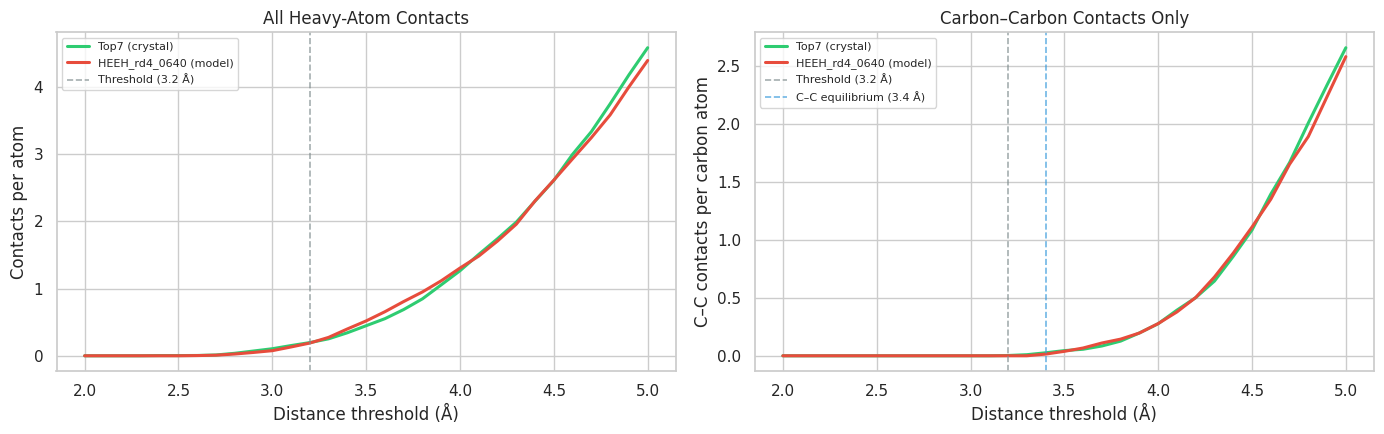

In [14]:
def scan_thresholds(coords, residue_ids, elements, thresholds):
    """Return all-atom and C-C-only contact counts per atom across thresholds."""
    dm = cdist(coords, coords, metric="euclidean")
    gap = np.abs(residue_ids[:, np.newaxis] - residue_ids[np.newaxis, :])
    valid = gap > 1
    n = coords.shape[0]
    elem_arr = np.array(elements)
    c_mask = elem_arr == "C"
    cc_pair = c_mask[:, np.newaxis] & c_mask[np.newaxis, :]
    n_c = int(np.sum(c_mask))

    all_counts, cc_counts = [], []
    for t in thresholds:
        m = (dm < t) & valid
        all_counts.append(int(np.sum(m)) // 2 / n)
        cc_counts.append(int(np.sum(m & cc_pair)) // 2 / n_c if n_c > 0 else 0)
    return all_counts, cc_counts


thresholds = np.arange(2.0, 5.05, 0.1)
top7_all, top7_cc = scan_thresholds(top7_parsed[0], top7_parsed[1], top7_parsed[2], thresholds)
heeh_all, heeh_cc = scan_thresholds(heeh_parsed[0], heeh_parsed[1], heeh_parsed[2], thresholds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# All-atom contacts
ax1.plot(thresholds, top7_all, color="#2ecc71", lw=2.2, label="Top7 (crystal)")
ax1.plot(thresholds, heeh_all, color="#e74c3c", lw=2.2, label="HEEH_rd4_0640 (model)")
ax1.axvline(x=3.2, color="#7f8c8d", ls="--", lw=1.2, alpha=0.7, label="Threshold (3.2 Å)")
ax1.set_xlabel("Distance threshold (Å)")
ax1.set_ylabel("Contacts per atom")
ax1.set_title("All Heavy-Atom Contacts")
ax1.legend(fontsize=8)

# C–C only contacts
ax2.plot(thresholds, top7_cc, color="#2ecc71", lw=2.2, label="Top7 (crystal)")
ax2.plot(thresholds, heeh_cc, color="#e74c3c", lw=2.2, label="HEEH_rd4_0640 (model)")
ax2.axvline(x=3.2, color="#7f8c8d", ls="--", lw=1.2, alpha=0.7, label="Threshold (3.2 Å)")
ax2.axvline(x=3.4, color="#3498db", ls="--", lw=1.2, alpha=0.7, label="C–C equilibrium (3.4 Å)")
ax2.set_xlabel("Distance threshold (Å)")
ax2.set_ylabel("C–C contacts per carbon atom")
ax2.set_title("Carbon–Carbon Contacts Only")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Pair-Type Breakdown

At 3.2 Å, most contacts are **N–O and C–O pairs** — many of which are legitimate hydrogen bonds (typical H-bond heavy-atom distance: 2.7–3.2 Å). This is not noise; it is a feature of the threshold. The **C–C count** isolates purely nonpolar packing clashes, which is what the pre-print specifically measured.

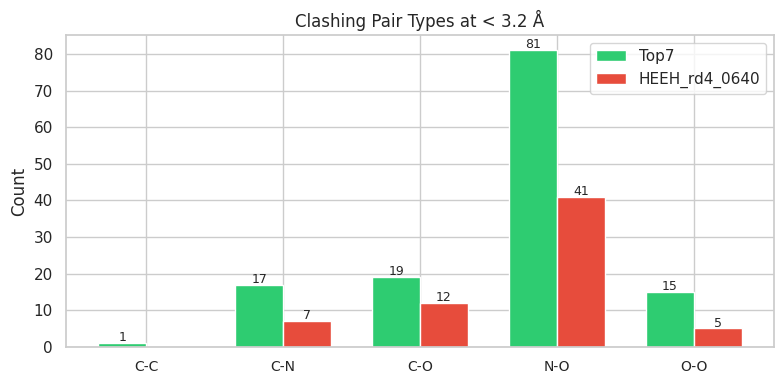

,Pair Type,Top7 (1QYS),HEEH_rd4_0640
0,C-C,1,0
1,C-N,17,7
2,C-O,19,12
3,N-O,81,41
4,O-O,15,5


In [15]:
# Pair-type breakdown side-by-side
all_types = sorted(set(list(top7_metrics["pair_type_counts"].keys()) +
                       list(heeh_metrics["pair_type_counts"].keys())))

breakdown = pd.DataFrame({
    "Pair Type": all_types,
    "Top7 (1QYS)": [top7_metrics["pair_type_counts"].get(t, 0) for t in all_types],
    "HEEH_rd4_0640": [heeh_metrics["pair_type_counts"].get(t, 0) for t in all_types],
})

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(all_types))
w = 0.35
ax.bar(x - w/2, breakdown["Top7 (1QYS)"], w, label="Top7", color="#2ecc71", edgecolor="white")
ax.bar(x + w/2, breakdown["HEEH_rd4_0640"], w, label="HEEH_rd4_0640", color="#e74c3c", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(all_types, fontsize=10)
ax.set_ylabel("Count")
ax.set_title(f"Clashing Pair Types at < {CLASH_THRESHOLD_ANGSTROM} Å")
ax.legend()
# Annotate
for i, (tv, hv) in enumerate(zip(breakdown["Top7 (1QYS)"], breakdown["HEEH_rd4_0640"])):
    if tv > 0: ax.text(i - w/2, tv + 0.5, str(tv), ha="center", fontsize=9)
    if hv > 0: ax.text(i + w/2, hv + 0.5, str(hv), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

breakdown

---

## Summary

In [16]:
# ============================================================
# COMPARISON TABLE
# ============================================================
comparison = pd.DataFrame({
    "Metric": [
        "Structure type",
        "Residues",
        "Total heavy atoms",
        "Carbon atoms",
        f"All-atom clashes (< {CLASH_THRESHOLD_ANGSTROM} Å)",
        "All-atom Clash Ratio",
        f"C–C clashes (< {CLASH_THRESHOLD_ANGSTROM} Å)",
        "C–C Clash Ratio",
        "Avg Core Distance (Å)",
    ],
    "Top7 (1QYS)": [
        "X-ray crystal (2.5 Å)",
        "91",
        f"{top7_metrics['Total_Atoms']:.0f}",
        f"{top7_metrics['Carbon_Atoms']:.0f}",
        f"{top7_metrics['Clash_Count']:.0f}",
        f"{top7_metrics['Clash_Ratio']:.6f}",
        f"{top7_metrics['CC_Clash_Count']:.0f}",
        f"{top7_metrics['CC_Clash_Ratio']:.6f}",
        f"{top7_metrics['Avg_Core_Distance']:.4f}",
    ],
    "HEEH_rd4_0640": [
        "Rosetta design model",
        "43",
        f"{heeh_metrics['Total_Atoms']:.0f}",
        f"{heeh_metrics['Carbon_Atoms']:.0f}",
        f"{heeh_metrics['Clash_Count']:.0f}",
        f"{heeh_metrics['Clash_Ratio']:.6f}",
        f"{heeh_metrics['CC_Clash_Count']:.0f}",
        f"{heeh_metrics['CC_Clash_Ratio']:.6f}",
        f"{heeh_metrics['Avg_Core_Distance']:.4f}",
    ],
})
comparison

,Metric,Top7 (1QYS),HEEH_rd4_0640
0,Structure type,X-ray crystal (2.5 Å),Rosetta design model
1,Residues,91,43
2,Total heavy atoms,677,343
3,Carbon atoms,427,209
4,All-atom clashes (< 3.2 Å),133,65
5,All-atom Clash Ratio,0.196455,0.189504
6,C–C clashes (< 3.2 Å),1,0
7,C–C Clash Ratio,0.002342,0.000000
8,Avg Core Distance (Å),4.2861,4.2603


In [19]:
# ============================================================
# SUMMARY
# ============================================================
summary = f"""
{'='*72}
 STERIC CLASH ANALYSIS — SOFT-CLASH REGIME ({CLASH_THRESHOLD_ANGSTROM} Å)
 Klavins Lab, University of Washington
{'='*72}

 THRESHOLD RATIONALE
 ───────────────────
   C–C van der Waals contact distance:  3.40 Å  (1.70 + 1.70, Bondi 1964)
   Detection threshold:                 {CLASH_THRESHOLD_ANGSTROM:.1f} Å
   Overlap into repulsive wall:          0.20 Å
   Regime: soft clashes — the bias identified in the 2025 pre-print

 METRIC COMPARISON
 ─────────────────
   {'Metric':<32s} {'Top7 (1QYS)':>16s} {'HEEH_rd4_0640':>16s}
   {'─'*32}  {'─'*16}  {'─'*16}
   {'Structure type':<32s} {'X-ray (2.5 Å)':>16s} {'Rosetta model':>16s}
   {'Total heavy atoms':<32s} {top7_metrics['Total_Atoms']:>16.0f} {heeh_metrics['Total_Atoms']:>16.0f}
   {'Carbon atoms':<32s} {top7_metrics['Carbon_Atoms']:>16.0f} {heeh_metrics['Carbon_Atoms']:>16.0f}
   {'All-atom clashes (< 3.2 Å)':<32s} {top7_metrics['Clash_Count']:>16.0f} {heeh_metrics['Clash_Count']:>16.0f}
   {'All-atom Clash Ratio':<32s} {top7_metrics['Clash_Ratio']:>16.6f} {heeh_metrics['Clash_Ratio']:>16.6f}
   {'C–C clashes (< 3.2 Å)':<32s} {top7_metrics['CC_Clash_Count']:>16.0f} {heeh_metrics['CC_Clash_Count']:>16.0f}
   {'C–C Clash Ratio':<32s} {top7_metrics['CC_Clash_Ratio']:>16.6f} {heeh_metrics['CC_Clash_Ratio']:>16.6f}
   {'Avg Core Distance (Å)':<32s} {top7_metrics['Avg_Core_Distance']:>16.4f} {heeh_metrics['Avg_Core_Distance']:>16.4f}

 PAIR-TYPE BREAKDOWN (< 3.2 Å)
 ──────────────────────────────"""
for pt in all_types:
    t_val = top7_metrics["pair_type_counts"].get(pt, 0)
    h_val = heeh_metrics["pair_type_counts"].get(pt, 0)
    summary += f"\n   {pt:<32s} {t_val:>16d} {h_val:>16d}"

summary += f"""

 INTERPRETATION
 ──────────────
   All-atom Clash Ratio: The two proteins have similar all-atom ratios
   at 3.2 Å (~0.19). This is because the signal is dominated by N–O
   and C–O contacts — many of which are legitimate hydrogen bonds
   (heavy-atom H-bond distance: 2.7–3.2 Å). These are not clashes.

   C–C Clash Ratio: Top7 (crystal structure) shows {top7_metrics['CC_Clash_Count']:.0f} C–C contact
   at < 3.2 Å. HEEH_rd4_0640 (Rosetta model) shows {heeh_metrics['CC_Clash_Count']:.0f}. Both are
   very low — Rosetta's minimizer resolves most C–C overlaps even in
   the soft-clash regime.

   The pre-print's key insight is that the overpacking signal only
   emerges when comparing design models AGAINST their experimental
   crystal structures (not when analyzing either in isolation). The
   ~30%% excess C–C clashes in design models vs. crystals is a
   distributional shift detectable via KL divergence on atom-pair
   distance distributions — not via a simple per-protein threshold.

 NEXT STEPS
 ──────────
   1. Obtain crystal structures for failed HEEH designs (if available)
      and compare design model vs. crystal at the C–C distance level.
   2. Compute atom-pair distance DISTRIBUTIONS (not just counts) and
      compare using KL divergence, following the pre-print's method.
   3. Add buried NPSA (solvent-accessible surface area) as a feature —
      the dominant stability determinant in Rocklin et al. (2017).
   4. Retrain ML model on real PDB data at the recalibrated threshold.

 REFERENCES
 ──────────
   [1] Haddox et al. (2025). bioRxiv 10.64898/2025.12.12.691241v1
   [2] Kuhlman et al. (2003). Science 302:1364-1368. PMID 14631033
   [3] Rocklin et al. (2017). Science 357:168-175. PMID 28706065
   [4] PDB 1QYS: rcsb.org/structure/1qys
   [5] Bondi (1964). VDW radii. J Phys Chem 68(3):441-451
{'='*72}
"""

print(summary)


 STERIC CLASH ANALYSIS — SOFT-CLASH REGIME (3.2 Å)
 Klavins Lab, University of Washington

 THRESHOLD RATIONALE
 ───────────────────
   C–C van der Waals contact distance:  3.40 Å  (1.70 + 1.70, Bondi 1964)
   Detection threshold:                 3.2 Å
   Overlap into repulsive wall:          0.20 Å
   Regime: soft clashes — the bias identified in the 2025 pre-print

 METRIC COMPARISON
 ─────────────────
   Metric                                Top7 (1QYS)    HEEH_rd4_0640
   ────────────────────────────────  ────────────────  ────────────────
   Structure type                      X-ray (2.5 Å)    Rosetta model
   Total heavy atoms                             677              343
   Carbon atoms                                  427              209
   All-atom clashes (< 3.2 Å)                    133               65
   All-atom Clash Ratio                     0.196455         0.189504
   C–C clashes (< 3.2 Å)                           1                0
   C–C Clash Ratio           

---

## Discussion

### What the 3.2 Å Threshold Reveals (and What It Doesn't)

At the **all-atom level**, both proteins show similar clash ratios (~0.19) because the 3.2 Å window captures many legitimate **hydrogen bonds** (N–O and C–O contacts at 2.7–3.2 Å). These are stabilizing interactions, not steric violations.

At the **C–C level**, both proteins show very few clashes — Rosetta's energy minimizer resolves most C–C overlaps even in the soft-clash regime. This is expected: a Rosetta design model (HEEH) will always satisfy its own internal distance constraints.

### Why Single-Structure Analysis Is Insufficient

The [pre-print's](https://www.biorxiv.org/content/10.64898/2025.12.12.691241v1) critical insight is that overpacking is a **distributional** phenomenon. The signal emerges only when comparing **design models against their experimental crystal structures** — crystal structures consistently show ~30% fewer C–C contacts at close range ([Rosetta Commons](https://rosettacommons.org/2026/01/28/using-protein-design-experiments-to-guide-energy-function-development/)). This is measured via **KL divergence on atom-pair distance distributions**, not by thresholding individual structures.

A single-structure, single-threshold analysis (like this notebook) can detect catastrophic hard clashes but cannot detect the subtle distributional bias in `fa_rep`. To replicate the pre-print's methodology, the next iteration should:

1. Obtain matched pairs (design model + crystal structure) for the same proteins.
2. Compute full C–C distance distributions (histograms from 2.5–5.0 Å).
3. Compare distributions via KL divergence.
4. Incorporate buried nonpolar surface area (NPSA) — the dominant stability predictor in [Rocklin *et al.* (2017)](https://www.science.org/doi/10.1126/science.aan0693).

---

## References

1. Haddox, Rocklin, Park, Baker, DiMaio *et al.* (2025). *bioRxiv*. [10.64898/2025.12.12.691241v1](https://www.biorxiv.org/content/10.64898/2025.12.12.691241v1)  
2. Kuhlman *et al.* (2003). *Science* 302:1364–1368. [PMID 14631033](https://pubmed.ncbi.nlm.nih.gov/14631033/)  
3. Rocklin *et al.* (2017). *Science* 357:168–175. [PMID 28706065](https://pubmed.ncbi.nlm.nih.gov/28706065/)  
4. PDB 1QYS. [rcsb.org/structure/1qys](https://www.rcsb.org/structure/1qys)  
5. Rosetta Commons (2026). [Summary](https://rosettacommons.org/2026/01/28/using-protein-design-experiments-to-guide-energy-function-development/)  
6. Ramachandran *et al.* (2011). *Proteins*. [PMC3058769](https://pmc.ncbi.nlm.nih.gov/articles/PMC3058769/)  
7. Bondi (1964). *J. Phys. Chem.* 68(3):441–451. [Wikipedia table](https://en.wikipedia.org/wiki/Van_der_Waals_radius)  

---
*Prepared for the Klavins Lab, University of Washington. March 2026.*